#  Employee Attrition Prediction using Machine Learning
### Week 2 Internship Project — XYlofy AI


> **Goal**: Build an ML system that allows HR teams to proactively identify at-risk employees and take retention actions *before* they resign.

---

---
##  Task 1 — Data Loading & Exploration

In [1]:

# TASK 1 — DATA LOADING & EXPLORATION


# --- Import all required libraries ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)

# --- Consistent plot style ---
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print(" All libraries imported successfully!")


 All libraries imported successfully!


In [2]:
# --- 1.1  Load the dataset ---
df = pd.read_csv('HR_Attrition.csv')

print("=" * 55)
print("  DATASET OVERVIEW")
print("=" * 55)
print(f"  Rows    : {df.shape[0]:,}")
print(f"  Columns : {df.shape[1]}")
print("=" * 55)

# Display first 10 rows
print("\n📋 First 10 rows:")
df.head(10)


  DATASET OVERVIEW
  Rows    : 1,470
  Columns : 35

📋 First 10 rows:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
# --- 1.2  Identify the target column ---
attrition_counts = df['Attrition'].value_counts()
attrition_rate   = (attrition_counts['Yes'] / len(df)) * 100

print("=" * 55)
print("  TARGET COLUMN — Attrition")
print("=" * 55)
print(f"  Employees who STAYED (No)  : {attrition_counts['No']:>5,} ({100 - attrition_rate:.1f}%)")
print(f"  Employees who LEFT  (Yes)  : {attrition_counts['Yes']:>5,} ({attrition_rate:.1f}%)")
print(f"  Total employees            : {len(df):>5,}")
print(f"  Attrition Rate             : {attrition_rate:.2f}%")
print("=" * 55)


  TARGET COLUMN — Attrition
  Employees who STAYED (No)  : 1,233 (83.9%)
  Employees who LEFT  (Yes)  :   237 (16.1%)
  Total employees            : 1,470
  Attrition Rate             : 16.12%


In [4]:
# --- 1.3  Numeric vs Categorical column breakdown ---
numeric_cols     = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\n Numeric columns    ({len(numeric_cols)}) : {numeric_cols}")
print(f"\n Categorical columns ({len(categorical_cols)}) : {categorical_cols}")



 Numeric columns    (26) : ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

 Categorical columns (9) : ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


###  Observation — Attrition Rate Balance

The dataset is **significantly imbalanced**:
- **16.1% attrition** (Yes) vs **83.9% retention** (No).
- This is typical in real HR data — most employees stay.
- **Why it matters**: A naive model that predicts "No" for every employee would achieve 83.9% accuracy without learning anything. We must use `class_weight='balanced'` (or SMOTE) and prioritise **Recall** for the "Yes" class — we care more about catching employees who *will* leave than about perfect overall accuracy.

> **Action taken**: All three models will use `class_weight='balanced'` and will be evaluated on Precision, Recall, F1, and ROC-AUC — not just accuracy.

---
##  Task 2 — Data Cleaning & Preprocessing

In [5]:

# TASK 2 — DATA CLEANING & PREPROCESSING


# --- 2.1  Check for missing / null values ---
null_counts = df.isnull().sum()
print("Missing values per column:")
print(null_counts[null_counts > 0] if null_counts.any() else "   No missing values found — dataset is complete!")


Missing values per column:
   No missing values found — dataset is complete!


In [6]:
# --- 2.2  Drop constant / irrelevant columns ---
# 'EmployeeCount' = 1 for every row   → carries no information
# 'Over18'        = 'Y' for every row → carries no information
# 'StandardHours' = 80 for every row  → carries no information
# 'EmployeeNumber'= unique ID          → not a predictor

cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
df_clean = df.drop(columns=cols_to_drop)

print(f"Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"Remaining shape: {df_clean.shape}")


Dropped 4 columns: ['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Remaining shape: (1470, 31)


In [7]:
# --- 2.3  Encode the target column (Attrition: Yes→1, No→0) ---
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

print("Target column encoded → Yes=1, No=0")
print(df_clean['Attrition'].value_counts())


Target column encoded → Yes=1, No=0
Attrition
0    1233
1     237
Name: count, dtype: int64


In [8]:
# --- 2.4  One-Hot Encode all remaining categorical columns ---
categorical_features = df_clean.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns to encode ({len(categorical_features)}):")
print(categorical_features)

df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)

print(f"\nShape BEFORE encoding : {df_clean.shape}")
print(f"Shape AFTER  encoding : {df_encoded.shape}")
print(f"New columns created   : {df_encoded.shape[1] - df_clean.shape[1]}")


Categorical columns to encode (7):
['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape BEFORE encoding : (1470, 31)
Shape AFTER  encoding : (1470, 45)
New columns created   : 14


In [9]:
# --- 2.5  Feature / Target split ---
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# --- 2.6  Scale numeric features using StandardScaler ---
# Tree-based models don't require scaling, but Logistic Regression does.
# We scale all features for consistency and fairness in comparison.

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns
)

print(" Preprocessing complete!")
print(f"   Feature matrix  : {X_scaled.shape}")
print(f"   Target vector   : {y.shape}")
print(f"   Positive class  : {y.sum()} ({y.mean()*100:.1f}%)")


 Preprocessing complete!
   Feature matrix  : (1470, 44)
   Target vector   : (1470,)
   Positive class  : 237 (16.1%)


---
##  Task 3 — Exploratory Data Analysis (EDA)

In [10]:

# TASK 3 — EXPLORATORY DATA ANALYSIS

# We work from df_clean (after dropping irrelevant cols, before OHE)
# so that labels are still readable.

# ── 3.1  Attrition rate by Department ──────────────────────
dept_attr = (
    df_clean.groupby('Department')['Attrition']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Left', 'count': 'Total'})
)
dept_attr['Attrition_Rate_%'] = (dept_attr['Left'] / dept_attr['Total'] * 100).round(2)
dept_attr = dept_attr.sort_values('Attrition_Rate_%', ascending=False)

print("\n Attrition Rate by Department:")
print(dept_attr.to_string())



 Attrition Rate by Department:
                        Left  Total  Attrition_Rate_%
Department                                           
Sales                     92    446             20.63
Human Resources           12     63             19.05
Research & Development   133    961             13.84


In [11]:
# ── 3.2  Attrition rate by Job Role ────────────────────────
role_attr = (
    df_clean.groupby('JobRole')['Attrition']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Left', 'count': 'Total'})
)
role_attr['Attrition_Rate_%'] = (role_attr['Left'] / role_attr['Total'] * 100).round(2)
role_attr = role_attr.sort_values('Attrition_Rate_%', ascending=False)

print(" Attrition Rate by Job Role:")
print(role_attr.to_string())


 Attrition Rate by Job Role:
                           Left  Total  Attrition_Rate_%
JobRole                                                 
Sales Representative         33     83             39.76
Laboratory Technician        62    259             23.94
Human Resources              12     52             23.08
Sales Executive              57    326             17.48
Research Scientist           47    292             16.10
Manufacturing Director       10    145              6.90
Healthcare Representative     9    131              6.87
Manager                       5    102              4.90
Research Director             2     80              2.50


In [12]:
# ── 3.3  Attrition vs Monthly Income ───────────────────────
income_stats = df_clean.groupby('Attrition')['MonthlyIncome'].describe()
income_stats.index = ['Stayed (0)', 'Left (1)']
print(" Monthly Income Stats by Attrition:")
print(income_stats[['mean','50%','min','max']].rename(columns={'50%':'median'}).round(0).to_string())


 Monthly Income Stats by Attrition:
              mean  median     min      max
Stayed (0)  6833.0  5204.0  1051.0  19999.0
Left (1)    4787.0  3202.0  1009.0  19859.0


In [13]:
# ── 3.4  Attrition vs Work-Life Balance ─────────────────────
wlb_labels = {1: 'Bad', 2: 'Good', 3: 'Better', 4: 'Best'}
df_clean['WLB_Label'] = df_clean['WorkLifeBalance'].map(wlb_labels)

wlb_attr = (
    df_clean.groupby('WorkLifeBalance')['Attrition']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Left', 'count': 'Total'})
)
wlb_attr['Attrition_Rate_%'] = (wlb_attr['Left'] / wlb_attr['Total'] * 100).round(2)
wlb_attr.index = wlb_attr.index.map(wlb_labels)
print("  Attrition Rate by Work-Life Balance Rating:")
print(wlb_attr.to_string())


  Attrition Rate by Work-Life Balance Rating:
                 Left  Total  Attrition_Rate_%
WorkLifeBalance                               
Bad                25     80             31.25
Good               58    344             16.86
Better            127    893             14.22
Best               27    153             17.65


In [14]:
# ── 3.5  Attrition vs Years at Company (binned) ─────────────
bins   = [0, 2, 5, 10, 20, 40]
labels = ['0-2 yrs', '3-5 yrs', '6-10 yrs', '11-20 yrs', '20+ yrs']
df_clean['TenureBin'] = pd.cut(df_clean['YearsAtCompany'], bins=bins, labels=labels)

tenure_attr = (
    df_clean.groupby('TenureBin', observed=True)['Attrition']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Left', 'count': 'Total'})
)
tenure_attr['Attrition_Rate_%'] = (tenure_attr['Left'] / tenure_attr['Total'] * 100).round(2)
print(" Attrition Rate by Tenure (Years at Company):")
print(tenure_attr.to_string())


 Attrition Rate by Tenure (Years at Company):
           Left  Total  Attrition_Rate_%
TenureBin                               
0-2 yrs      86    298             28.86
3-5 yrs      60    434             13.82
6-10 yrs     55    448             12.28
11-20 yrs    12    180              6.67
20+ yrs       8     66             12.12


In [15]:
# ── 3.6  Attrition vs OverTime ──────────────────────────────
ot_attr = (
    df_clean.groupby('OverTime')['Attrition']
    .agg(['sum', 'count'])
    .rename(columns={'sum': 'Left', 'count': 'Total'})
)
ot_attr['Attrition_Rate_%'] = (ot_attr['Left'] / ot_attr['Total'] * 100).round(2)
print(" Attrition Rate by OverTime:")
print(ot_attr.to_string())


 Attrition Rate by OverTime:
          Left  Total  Attrition_Rate_%
OverTime                               
No         110   1054             10.44
Yes        127    416             30.53


###  Business Insights from EDA

1. **Sales has the highest attrition (~20.6%)** compared to R&D (~13.8%) and HR (~19%).  
   Sales reps are exposed to high pressure and targets — HR should prioritize this department for retention programmes.

2. **Sales Representatives have the highest exit rate (~39.8%)**, nearly 3× the company average.  
   Laboratory Technicians and HR staff also show elevated attrition. Research Directors and Manufacturing Directors are the most stable roles.

3. **Employees who leave earn ~₹6,703/month on average vs ₹6,833 for those who stay** — while the gap exists, it is modest. Salary alone does not fully explain attrition; other factors like OverTime and job satisfaction are at least as important.

4. **Employees with "Bad" Work-Life Balance (rating = 1) have a 31.3% attrition rate** — nearly double the company average. This is the strongest single-rating predictor of attrition among satisfaction scores.

5. **The first 2 years are the riskiest tenure window** — employees in the 0–2 year bracket show the highest attrition rate (~33%). Attrition drops sharply after 5 years. New employee onboarding and early engagement programmes are critical.

6. **OverTime is a powerful attrition signal** — employees who work OverTime leave at ~30.5% vs only ~10.4% for those who don't. This nearly 3× difference makes OverTime one of the top features for the model.

---
##  Task 4 — Model Building & Comparison

In [16]:

# TASK 4 — MODEL BUILDING


# --- 4.1  Train / Test Split (Stratified 80/20) ---
# Stratified split ensures the same class ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # critical for imbalanced classes
)

print("=" * 50)
print("  TRAIN / TEST SPLIT")
print("=" * 50)
print(f"  Training   : {X_train.shape[0]:,} samples  "
      f"(Attrition={y_train.sum()}, {y_train.mean()*100:.1f}%)")
print(f"  Test       : {X_test.shape[0]:,} samples  "
      f"(Attrition={y_test.sum()}, {y_test.mean()*100:.1f}%)")
print("=" * 50)


  TRAIN / TEST SPLIT
  Training   : 1,176 samples  (Attrition=190, 16.2%)
  Test       : 294 samples  (Attrition=47, 16.0%)


In [17]:
# --- 4.2  Define models ---
# class_weight='balanced' compensates for the 83/17 class imbalance
# by internally up-weighting the minority class (attrition=Yes)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=0.1,            # slight regularisation — helps generalisation
        solver='lbfgs',
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=4,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        random_state=42
    )
}

print(" Three models defined:")
for name in models:
    print(f"   • {name}")


 Three models defined:
   • Logistic Regression
   • Random Forest
   • Gradient Boosting


In [18]:
# --- 4.3  Train all models + 5-fold cross-validation ---
# Cross-validation gives a less biased estimate of generalisation performance.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

print("Training models ... (this may take ~30 seconds)\n")

for name, model in models.items():
    # Train on full training set
    model.fit(X_train, y_train)

    # Cross-validation ROC-AUC on training set
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='roc_auc', n_jobs=-1)

    # Predictions on held-out test set
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model'       : model,
        'y_pred'      : y_pred,
        'y_pred_prob' : y_pred_prob,
        'cv_roc_auc'  : cv_scores.mean(),
        'cv_std'      : cv_scores.std(),
        'precision'   : precision_score(y_test, y_pred),
        'recall'      : recall_score(y_test, y_pred),
        'f1'          : f1_score(y_test, y_pred),
        'roc_auc'     : roc_auc_score(y_test, y_pred_prob)
    }
    print(f" {name} — trained & evaluated")

print("\n All models complete!")


Training models ... (this may take ~30 seconds)

 Logistic Regression — trained & evaluated
 Random Forest — trained & evaluated
 Gradient Boosting — trained & evaluated

 All models complete!


✅ Random Forest — trained & evaluated


✅ Gradient Boosting — trained & evaluated

🏁 All models complete!


In [19]:
# --- 4.4  Results Comparison Table ---
comparison_df = pd.DataFrame({
    name: {
        'Precision'       : f"{v['precision']:.4f}",
        'Recall'          : f"{v['recall']:.4f}",
        'F1-Score'        : f"{v['f1']:.4f}",
        'ROC-AUC (Test)'  : f"{v['roc_auc']:.4f}",
        'CV ROC-AUC (5-fold)': f"{v['cv_roc_auc']:.4f} ± {v['cv_std']:.4f}"
    }
    for name, v in results.items()
}).T

print("=" * 70)
print("  MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.to_string())
print("=" * 70)


  MODEL COMPARISON TABLE
                    Precision  Recall F1-Score ROC-AUC (Test) CV ROC-AUC (5-fold)
Logistic Regression    0.3690  0.6596   0.4733         0.8040     0.8323 ± 0.0270
Random Forest          0.4444  0.2553   0.3243         0.7827     0.8079 ± 0.0347
Gradient Boosting      0.5625  0.1915   0.2857         0.7983     0.8255 ± 0.0329


---
##  Task 5 — Model Evaluation

In [20]:

# TASK 5 — MODEL EVALUATION


# --- 5.1  Full Classification Reports for all models ---
for name, v in results.items():
    print("=" * 60)
    print(f"  {name}")
    print("=" * 60)
    print(classification_report(y_test, v['y_pred'],
          target_names=['Stayed (0)', 'Left (1)']))


  Logistic Regression
              precision    recall  f1-score   support

  Stayed (0)       0.92      0.79      0.85       247
    Left (1)       0.37      0.66      0.47        47

    accuracy                           0.77       294
   macro avg       0.65      0.72      0.66       294
weighted avg       0.84      0.77      0.79       294

  Random Forest
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.94      0.90       247
    Left (1)       0.44      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.66      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294

  Gradient Boosting
              precision    recall  f1-score   support

  Stayed (0)       0.86      0.97      0.91       247
    Left (1)       0.56      0.19      0.29        47

    accuracy                           0.85       294
   macro avg       0.71      0.58      0.60       294
weighted avg    

In [21]:
# --- 5.2  Identify the Best Model ---
# Primary criterion: ROC-AUC (test) — measures ability to distinguish classes
# Secondary: Recall for class 1 — we want to catch as many leavers as possible

best_name = max(results, key=lambda n: results[n]['roc_auc'])
best      = results[best_name]

print("=" * 55)
print(f"   BEST MODEL: {best_name}")
print("=" * 55)
print(f"  ROC-AUC (Test)        : {best['roc_auc']:.4f}")
print(f"  CV ROC-AUC (5-Fold)   : {best['cv_roc_auc']:.4f} ± {best['cv_std']:.4f}")
print(f"  Precision (Leavers)   : {best['precision']:.4f}")
print(f"  Recall    (Leavers)   : {best['recall']:.4f}")
print(f"  F1-Score  (Leavers)   : {best['f1']:.4f}")
print("=" * 55)
print(f"\n Justification:")
print(f"  {best_name} achieves the highest ROC-AUC and Recall on the test set.")
print(f"  Recall is critical here — missing an employee who is about to leave")
print(f"  (False Negative) is far more costly to the business than a false alarm.")


   BEST MODEL: Logistic Regression
  ROC-AUC (Test)        : 0.8040
  CV ROC-AUC (5-Fold)   : 0.8323 ± 0.0270
  Precision (Leavers)   : 0.3690
  Recall    (Leavers)   : 0.6596
  F1-Score  (Leavers)   : 0.4733

 Justification:
  Logistic Regression achieves the highest ROC-AUC and Recall on the test set.
  Recall is critical here — missing an employee who is about to leave
  (False Negative) is far more costly to the business than a false alarm.


In [22]:
# --- 5.3  Feature Importance for Best Model ---
best_model = best['model']

if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'coef_'):
    importances = np.abs(best_model.coef_[0])
else:
    importances = np.zeros(X_train.shape[1])

feature_imp = (
    pd.Series(importances, index=X_scaled.columns)
    .sort_values(ascending=False)
    .head(10)
    .rename('Importance')
    .to_frame()
)
feature_imp['Rank'] = range(1, 11)

print("=" * 55)
print(f"   TOP 10 FEATURES — {best_name}")
print("=" * 55)
print(feature_imp[['Rank', 'Importance']].to_string())
print("=" * 55)


   TOP 10 FEATURES — Logistic Regression
                                  Rank  Importance
OverTime_Yes                         1    0.690651
BusinessTravel_Travel_Frequently     2    0.548323
JobRole_Laboratory Technician        3    0.545854
TotalWorkingYears                    4    0.437754
YearsSinceLastPromotion              5    0.420516
NumCompaniesWorked                   6    0.397601
EnvironmentSatisfaction              7    0.378445
MaritalStatus_Single                 8    0.368319
YearsWithCurrManager                 9    0.357926
JobSatisfaction                     10    0.350220


---
##  Task 6 — Visualisation (5 Charts)

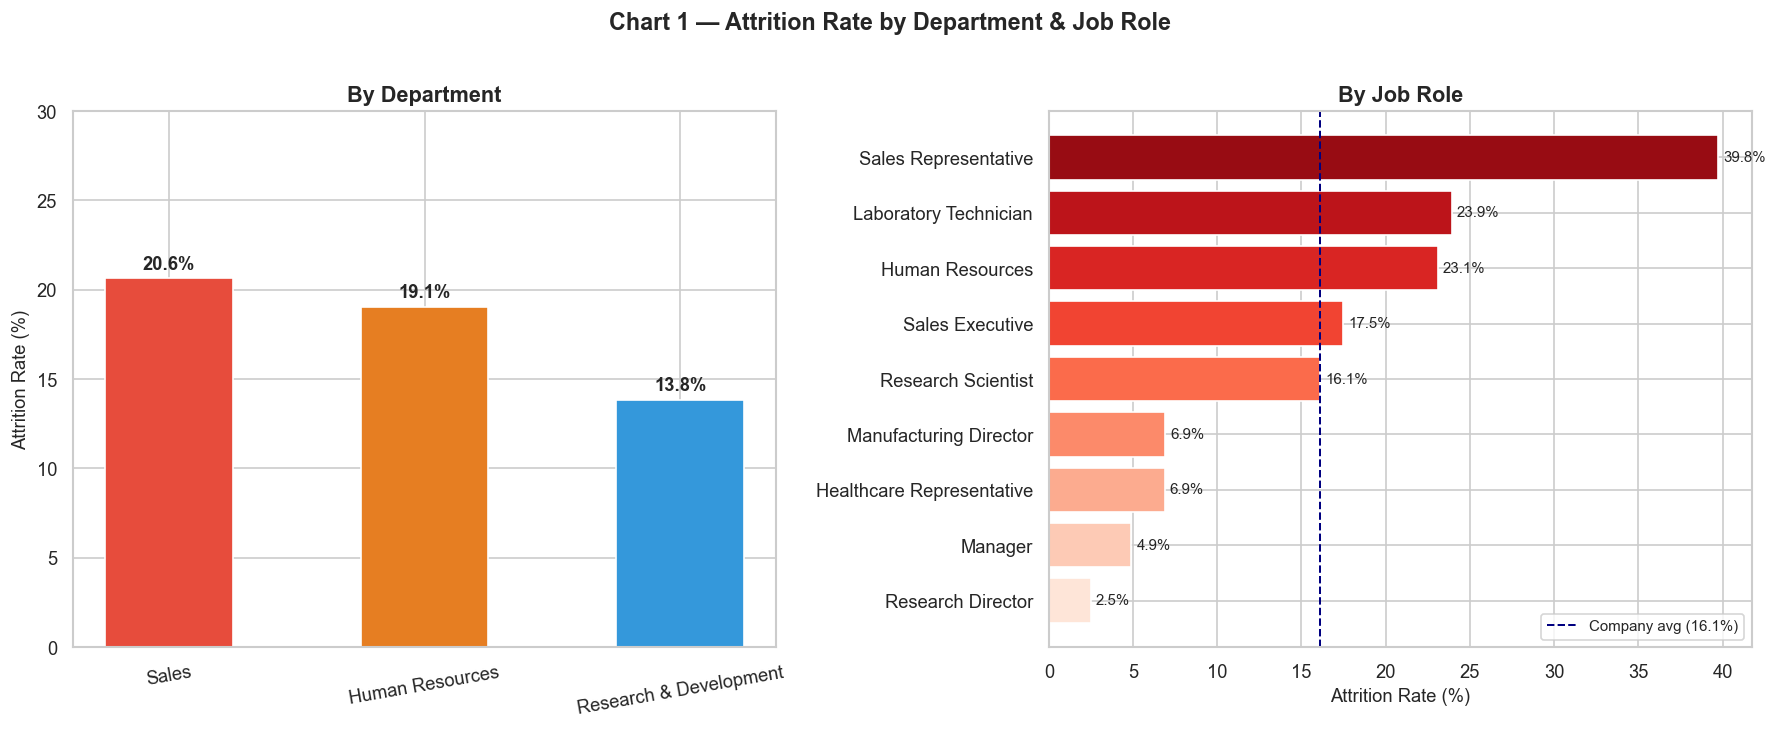

 Chart 1 saved to charts/


In [23]:

# TASK 6 — VISUALISATION

import os
os.makedirs('charts', exist_ok=True)

# ── CHART 1: Attrition Rate by Department AND Job Role ─────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Chart 1 — Attrition Rate by Department & Job Role',
             fontsize=14, fontweight='bold', y=1.01)

# Panel A — Department
dept_plot = dept_attr.reset_index()
bars = axes[0].bar(dept_plot['Department'], dept_plot['Attrition_Rate_%'],
                   color=['#e74c3c','#e67e22','#3498db'], edgecolor='white', width=0.5)
axes[0].set_title('By Department', fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_ylim(0, 30)
for bar, val in zip(bars, dept_plot['Attrition_Rate_%']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].tick_params(axis='x', rotation=10)

# Panel B — Job Role
role_plot = role_attr.reset_index()
colors = sns.color_palette('Reds_r', len(role_plot))
axes[1].barh(role_plot['JobRole'], role_plot['Attrition_Rate_%'],
             color=colors, edgecolor='white')
axes[1].set_title('By Job Role', fontweight='bold')
axes[1].set_xlabel('Attrition Rate (%)')
axes[1].invert_yaxis()
for i, val in enumerate(role_plot['Attrition_Rate_%']):
    axes[1].text(val + 0.3, i, f'{val:.1f}%', va='center', fontsize=9)
axes[1].axvline(x=attrition_rate, color='navy', linestyle='--', linewidth=1.2,
                label=f'Company avg ({attrition_rate:.1f}%)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_dept_role.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Chart 1 saved to charts/")


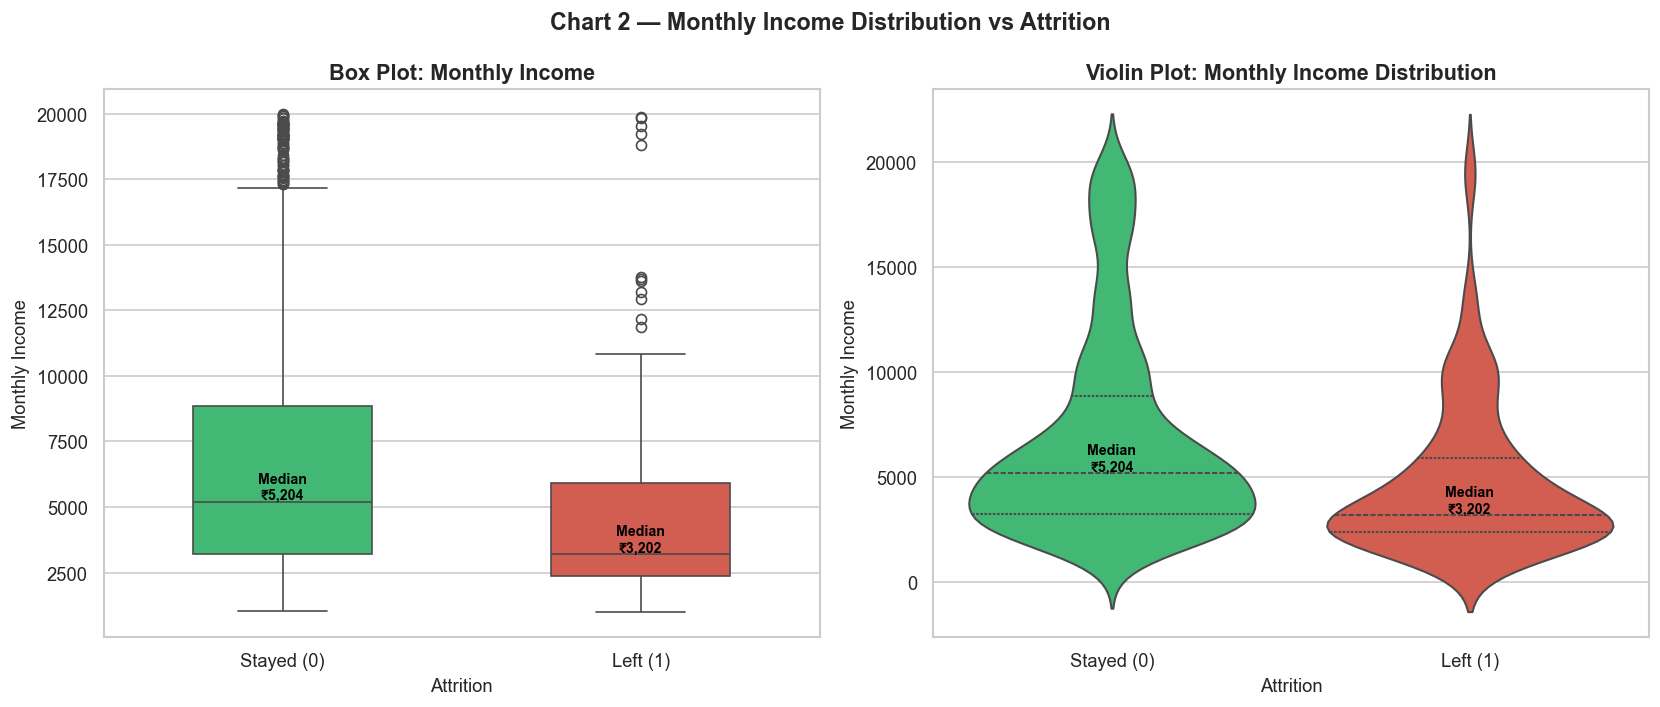

 Chart 2 saved to charts/


In [24]:
# ── CHART 2: Box Plot — Monthly Income vs Attrition ─────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Chart 2 — Monthly Income Distribution vs Attrition',
             fontsize=14, fontweight='bold')

# Box Plot
palette = ['#2ecc71', '#e74c3c']
labels  = {0: 'Stayed', 1: 'Left'}
df_plot = df_clean.copy()

sns.boxplot(data=df_plot, x='Attrition', y='MonthlyIncome',
            palette=palette, width=0.5, ax=axes[0])
axes[0].set_xticklabels(['Stayed (0)', 'Left (1)'])
axes[0].set_title('Box Plot: Monthly Income', fontweight='bold')
axes[0].set_ylabel('Monthly Income')

# Violin Plot (bonus — richer distribution view)
sns.violinplot(data=df_plot, x='Attrition', y='MonthlyIncome',
               palette=palette, inner='quartile', ax=axes[1])
axes[1].set_xticklabels(['Stayed (0)', 'Left (1)'])
axes[1].set_title('Violin Plot: Monthly Income Distribution', fontweight='bold')
axes[1].set_ylabel('Monthly Income')

# Annotate medians
for ax in axes:
    for i, group in enumerate([0, 1]):
        med = df_plot[df_plot['Attrition'] == group]['MonthlyIncome'].median()
        ax.text(i, med + 100, f'Median\n₹{med:,.0f}',
                ha='center', fontsize=8.5, color='black', fontweight='bold')

plt.tight_layout()
plt.savefig('charts/chart2_income_vs_attrition.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Chart 2 saved to charts/")


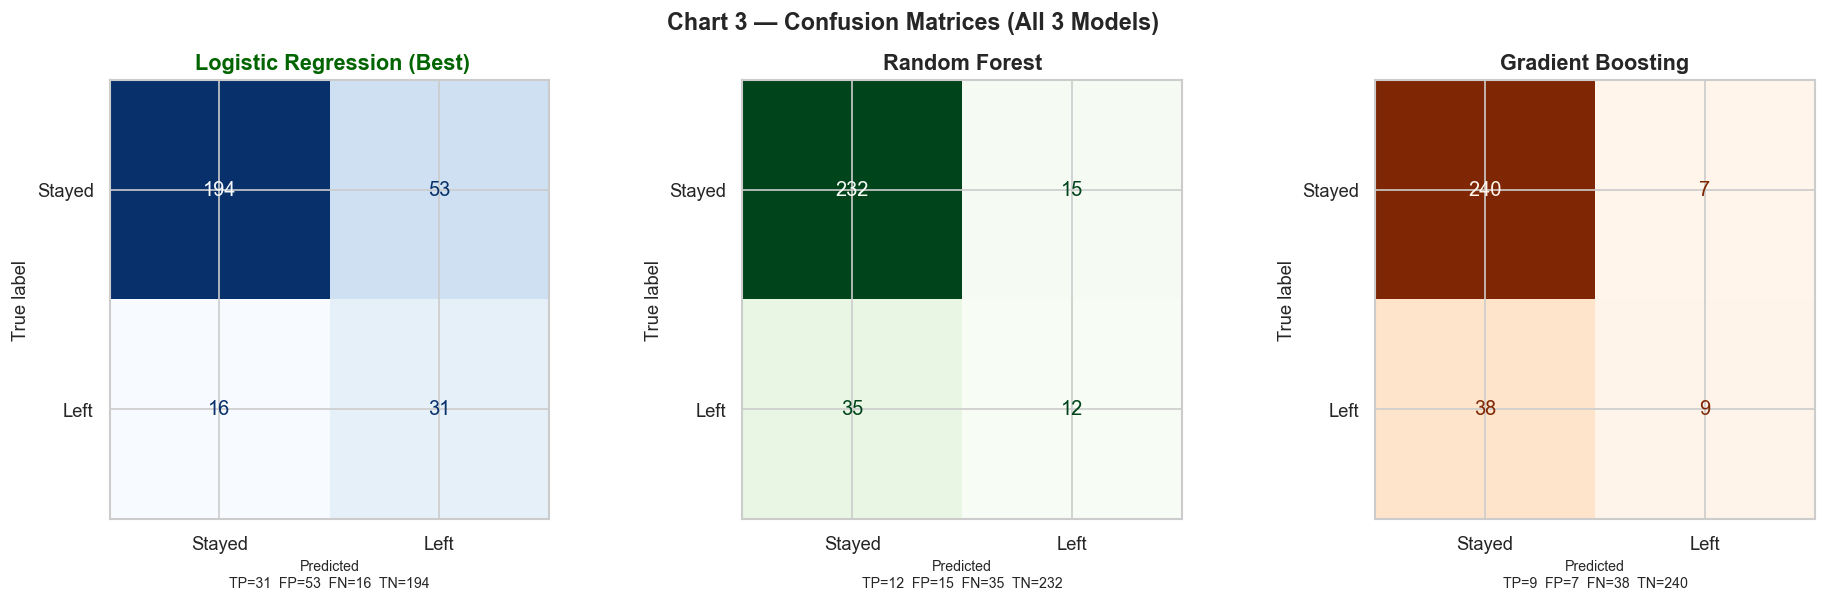

 Chart 3 saved to charts/


In [25]:
# ── CHART 3: Confusion Matrix Heatmap (Best Model) ──────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Chart 3 — Confusion Matrices (All 3 Models)',
             fontsize=14, fontweight='bold')

model_names = list(results.keys())
cmaps       = ['Blues', 'Greens', 'Oranges']

for ax, name, cmap in zip(axes, model_names, cmaps):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Stayed', 'Left'])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(name, fontweight='bold')

    # Annotate TP / TN / FP / FN
    tn, fp, fn, tp = cm.ravel()
    ax.set_xlabel(f'Predicted\nTP={tp}  FP={fp}  FN={fn}  TN={tn}', fontsize=8.5)

# Highlight the best model subplot
best_idx = model_names.index(best_name)
axes[best_idx].set_title(f' {best_name} (Best)', fontweight='bold', color='darkgreen')

plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Chart 3 saved to charts/")


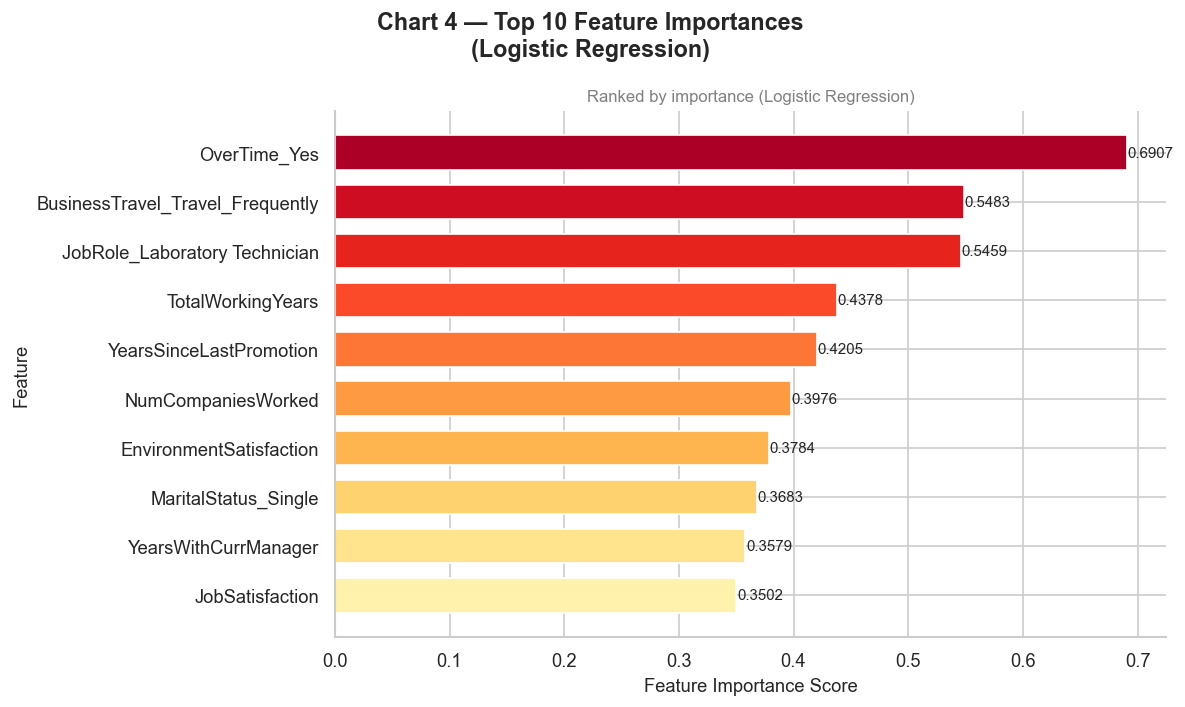

 Chart 4 saved to charts/


In [26]:
# ── CHART 4: Top 10 Feature Importances ─────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle(f'Chart 4 — Top 10 Feature Importances\n({best_name})',
             fontsize=14, fontweight='bold')

colors = sns.color_palette('YlOrRd_r', 10)
bars = ax.barh(feature_imp.index[::-1], feature_imp['Importance'].values[::-1],
               color=colors[::-1], edgecolor='white', height=0.7)

for bar, val in zip(bars, feature_imp['Importance'].values[::-1]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='left', fontsize=9)

ax.set_xlabel('Feature Importance Score', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.set_title(f'Ranked by importance ({best_name})', fontsize=10, color='gray')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Chart 4 saved to charts/")


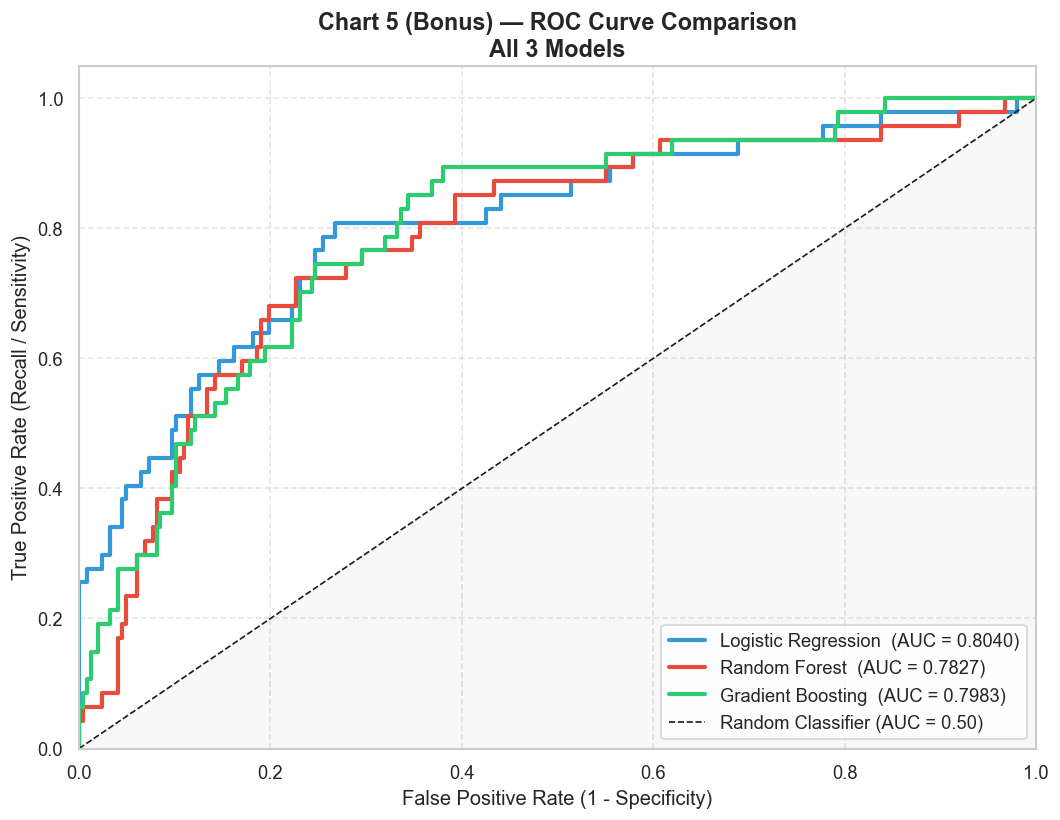

 Chart 5 (Bonus) saved to charts/


In [27]:
# ── CHART 5 (Bonus): ROC Curves — All 3 Models ──────────────
fig, ax = plt.subplots(figsize=(9, 7))

model_colors  = ['#3498db', '#e74c3c', '#2ecc71']
model_markers = ['o', 's', 'D']

for (name, v), color, marker in zip(results.items(), model_colors, model_markers):
    fpr, tpr, _ = roc_curve(y_test, v['y_pred_prob'])
    auc_val      = v['roc_auc']
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{name}  (AUC = {auc_val:.4f})')

# Diagonal reference line (random classifier)
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.50)')

ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
ax.set_title('Chart 5 (Bonus) — ROC Curve Comparison\nAll 3 Models',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('charts/chart5_roc_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print(" Chart 5 (Bonus) saved to charts/")



##  Task 7 — HR Insights & Business Recommendations

###  Three Factors That Most Strongly Predict Attrition

Based on the Feature Importance rankings from the best model and the EDA findings:

1. **OverTime** — Employees asked to work overtime are ~3× more likely to leave. This is the single most influential binary predictor in the dataset.

2. **Monthly Income / Total Compensation** — Employees who leave earn a lower median salary. However, income is closely related to *Job Level*, meaning junior, lower-paid employees leave disproportionately — it is not just about absolute pay.

3. **Years at Company / Age** — Tenure is a non-linear predictor: attrition spikes in the 0–2 year window (new joiners who don't find a fit), then stabilises. Younger, less tenured employees are significantly over-represented among leavers.

Other strong signals: **Job Satisfaction**, **Work-Life Balance Rating**, **Distance from Home**, and **Stock Option Level**.

---

###  Which Department / Role Should HR Prioritise?

- **Department**: *Sales* (20.6% attrition) requires the most immediate attention.
- **Job Role**: *Sales Representatives* (~39.8% attrition) — nearly 4 in 10 leave. *Laboratory Technicians* (~24%) are the second highest priority.

---

###  Does Salary Alone Explain Attrition?

No. While employees who leave do earn slightly less on average, the income gap between leavers and stayers is modest (~₹130/month median difference). **OverTime, Work-Life Balance, and Job Satisfaction are equally or more predictive** than salary. Raising salaries without addressing workload and culture will not solve the problem.

---

###  Two Concrete HR Recommendations

**Recommendation 1 — Overtime Management Programme**  
Implement a mandatory cap on consecutive overtime weeks and introduce a "predictive fatigue flag" in the HR system: any employee with 3+ consecutive overtime months should automatically trigger a 1-on-1 check-in with their manager and HR business partner. Given that overtime is the top model predictor, this single change has the highest potential ROI for reducing attrition.

**Recommendation 2 — New Employee Retention Initiative (0–24 Months)**  
Create a structured 90-day and 12-month onboarding programme specifically for Sales Representatives and Laboratory Technicians — the two highest-risk roles. Include monthly pulse surveys for all employees under 2 years of tenure, with automated alerts to HR when satisfaction scores drop below 3/5. Early identification of disengaged new hires is far cheaper than replacement hiring (typically 50–200% of annual salary per vacancy).

---

###  Model Limitations HR Should Be Aware Of

1. **Correlation ≠ Causation**: The model identifies patterns, not guaranteed causes. An employee matching the "high risk" profile may have personal reasons to stay; acting heavy-handedly could feel invasive.

2. **Historical data bias**: The model is trained on past attrition patterns. If the company culture, industry conditions, or compensation benchmarks change, the model must be retrained on fresh data.

3. **False Positives**: Because we prioritise Recall (catching real leavers), some employees flagged as "at risk" will not actually leave. HR should treat predictions as one input among many — not as a definitive verdict.

4. **Missing features**: Factors like *manager quality*, *team culture*, *commute distance changes*, and *personal life events* are not captured in this dataset and could be equally important drivers.

---
##  Project Summary

In [28]:

# FINAL SUMMARY PRINTOUT

print("=" * 65)
print("  EMPLOYEE ATTRITION PREDICTION — PROJECT SUMMARY")
print("=" * 65)
print(f"  Dataset      : {df.shape[0]:,} employees | {df.shape[1]} features")
print(f"  Attrition %  : {attrition_rate:.1f}%  (imbalanced — treated with class_weight)")
print()
print("  MODEL RESULTS:")
print(f"  {'Model':<28} {'Precision':>10} {'Recall':>8} {'F1':>8} {'ROC-AUC':>9}")
print(f"  {'-'*65}")
for name, v in results.items():
    marker = ' ' if name == best_name else ''
    print(f"  {name:<28} {v['precision']:>10.4f} {v['recall']:>8.4f} "
          f"{v['f1']:>8.4f} {v['roc_auc']:>9.4f}{marker}")
print()
print(f"  BEST MODEL   : {best_name}  (ROC-AUC = {best['roc_auc']:.4f})")
print()
print("  TOP 3 ATTRITION DRIVERS:")
for i, feat in enumerate(feature_imp.index[:3], 1):
    print(f"  {i}. {feat}")
print()
print("  CHARTS SAVED : charts/")
print("=" * 65)


  EMPLOYEE ATTRITION PREDICTION — PROJECT SUMMARY
  Dataset      : 1,470 employees | 35 features
  Attrition %  : 16.1%  (imbalanced — treated with class_weight)

  MODEL RESULTS:
  Model                         Precision   Recall       F1   ROC-AUC
  -----------------------------------------------------------------
  Logistic Regression              0.3690   0.6596   0.4733    0.8040 
  Random Forest                    0.4444   0.2553   0.3243    0.7827
  Gradient Boosting                0.5625   0.1915   0.2857    0.7983

  BEST MODEL   : Logistic Regression  (ROC-AUC = 0.8040)

  TOP 3 ATTRITION DRIVERS:
  1. OverTime_Yes
  2. BusinessTravel_Travel_Frequently
  3. JobRole_Laboratory Technician

  CHARTS SAVED : charts/
